# Pandas SQLite Tutorial
Tutorial instructions found [here](https://www.dataquest.io/blog/python-pandas-databases/)

### Preliminaries

In [1]:
import sqlite3

In [2]:
conn = sqlite3.connect('flights.db')
cur = conn.cursor()

cur.execute("select * from airlines limit 5;")
results = cur.fetchall()
print(results)

cur.close()
conn.close()

### Mapping Airports

In [3]:
import sqlite3

conn = sqlite3.connect("flights.db")
cur = conn.cursor()
coords = cur.execute("""
  select cast(longitude as float), 
  cast(latitude as float) 
  from airports;"""
).fetchall()

In [4]:
from mpl_toolkits.basemap import Basemap
%matplotlib inline
import matplotlib.pyplot as plt

/usr/lib/python3.7/site-packages/mpl_toolkits/basemap/__init__.py:1704: MatplotlibDeprecationWarning: The axesPatch function was deprecated in version 2.1. Use Axes.patch instead.
  limb = ax.axesPatch
/usr/lib/python3.7/site-packages/mpl_toolkits/basemap/__init__.py:1707: MatplotlibDeprecationWarning: The axesPatch function was deprecated in version 2.1. Use Axes.patch instead.
  if limb is not ax.axesPatch:


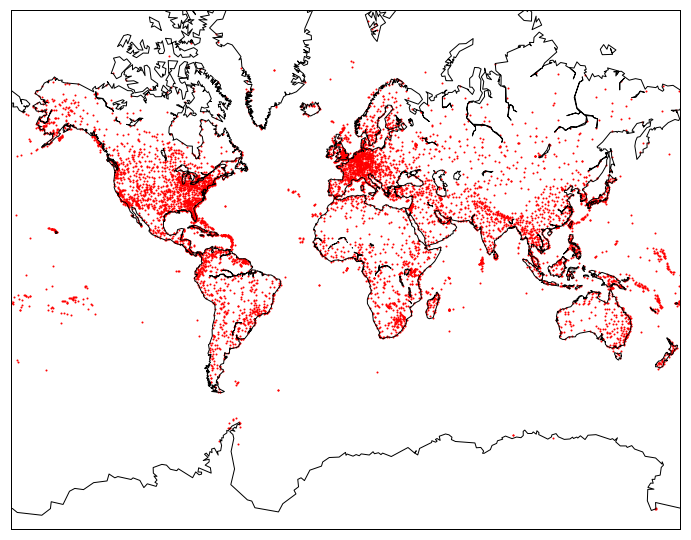

In [5]:
plt.figure(figsize=(12,12))
m = Basemap(
  projection='merc',
  llcrnrlat=-80,
  urcrnrlat=80,
  llcrnrlon=-180,
  urcrnrlon=180,
  lat_ts=20,
  resolution='c'
)
m.drawcoastlines()
m.drawmapboundary()

x, y = m([l[0] for l in coords], [l[1] for l in coords])

m.scatter(x, y, 1, marker='o', color='red')
plt.show()

In [6]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("flights.db")
df = pd.read_sql_query("select * from airlines limit 5;", conn)
df

,index,id,name,alias,iata,icao,callsign,country,active
0,0,1,Private flight,\N,-,None,None,None,Y
1,1,2,135 Airways,\N,None,GNL,GENERAL,United States,N
2,2,3,1Time Airline,\N,1T,RNX,NEXTIME,South Africa,Y
3,3,4,2 Sqn No 1 Elementary Flying Training School,\N,None,WYT,None,United Kingdom,N
4,4,5,213 Flight Unit,\N,None,TFU,None,Russia,N


In [7]:
df['country']

0              None
1     United States
2      South Africa
3    United Kingdom
4            Russia
Name: country, dtype: object

In [8]:
routes = pd.read_sql_query("""
                           select cast(sa.longitude as float) as source_lon, 
                           cast(sa.latitude as float) as source_lat,
                           cast(da.longitude as float) as dest_lon,
                           cast(da.latitude as float) as dest_lat
                           from routes 
                           inner join airports sa on
                           sa.id = routes.source_id
                           inner join airports da on
                           da.id = routes.dest_id;
                           """, 
                           conn)

/usr/lib/python3.7/site-packages/mpl_toolkits/basemap/__init__.py:1707: MatplotlibDeprecationWarning: The axesPatch function was deprecated in version 2.1. Use Axes.patch instead.
  if limb is not ax.axesPatch:


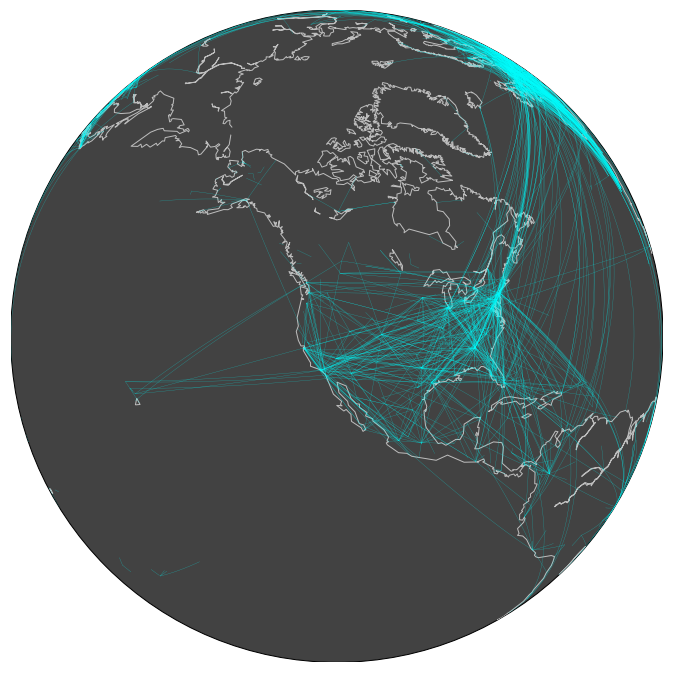

In [9]:
plt.figure(figsize=(12,12))
m = Basemap(
    projection='ortho',
    lat_0 = 40,
    lon_0 = -115,
    resolution='c')
m.drawmapboundary(fill_color='#424242')
m.drawcoastlines(color='#BDBDBD')

for name, row in routes.sample(3000).iterrows():
    if abs(row["source_lon"] - row["dest_lon"]) < 90:
        # Draw a great circle between source and dest airports.
        m.drawgreatcircle(
            row["source_lon"], 
            row["source_lat"], 
            row["dest_lon"],
            row["dest_lat"],
            linewidth=0.3,
            color='aqua',
            alpha=0.5,
        )
plt.show()

### My Own Work

In [10]:
ports = pd.read_sql_query("""
                           select *
                           from routes 
                           inner join airports sa on
                           sa.id = routes.source_id
                           """, 
                           conn)
ports.head()

,index,airline,airline_id,source,source_id,dest,dest_id,codeshare,stops,equipment,...,city,country,code,icao,latitude,longitude,altitude,offset,dst,timezone
0,0,2B,410,AER,2965,KZN,2990,None,0,CR2,...,Sochi,Russia,AER,URSS,43.449928,39.956589,89,4,N,Europe/Moscow
1,1,2B,410,ASF,2966,KZN,2990,None,0,CR2,...,Astrakhan,Russia,ASF,URWA,46.283333,48.006278,-65,4,N,Europe/Moscow
2,2,2B,410,ASF,2966,MRV,2962,None,0,CR2,...,Astrakhan,Russia,ASF,URWA,46.283333,48.006278,-65,4,N,Europe/Moscow
3,3,2B,410,CEK,2968,KZN,2990,None,0,CR2,...,Chelyabinsk,Russia,CEK,USCC,55.305836,61.503333,769,6,N,Asia/Yekaterinburg
4,4,2B,410,CEK,2968,OVB,4078,None,0,CR2,...,Chelyabinsk,Russia,CEK,USCC,55.305836,61.503333,769,6,N,Asia/Yekaterinburg


In [11]:
counts = ports['source_id'].value_counts()
counts = counts.to_frame('counts')
counts.head()

,counts
3682,915
3830,558
3364,535
507,527
1382,524


In [12]:
locs = ports.set_index('source_id').loc[counts.index][['latitude','longitude']]
ulocs = locs[~locs.index.duplicated(keep='first')]
ulocs.head()

,latitude,longitude
source_id,,
3682,33.636719,-84.428067
3830,41.978603,-87.904842
3364,40.080111,116.584556
507,51.4775,-0.461389
1382,49.012779,2.55


In [13]:
df = counts.join(ulocs)
df = df.apply(pd.to_numeric, errors='ignore')
df.head()

,counts,latitude,longitude
3682,915,33.636719,-84.428067
3830,558,41.978603,-87.904842
3364,535,40.080111,116.584556
507,527,51.477500,-0.461389
1382,524,49.012779,2.550000


/usr/lib/python3.7/site-packages/mpl_toolkits/basemap/__init__.py:1704: MatplotlibDeprecationWarning: The axesPatch function was deprecated in version 2.1. Use Axes.patch instead.
  limb = ax.axesPatch
/usr/lib/python3.7/site-packages/mpl_toolkits/basemap/__init__.py:1707: MatplotlibDeprecationWarning: The axesPatch function was deprecated in version 2.1. Use Axes.patch instead.
  if limb is not ax.axesPatch:


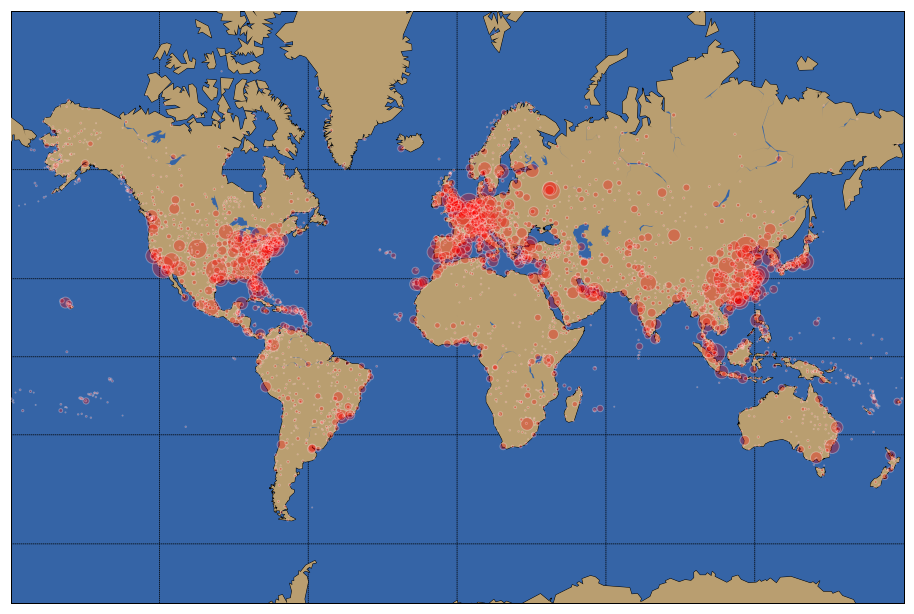

In [14]:
plt.figure(figsize=(16,16))
m = Basemap(
    projection='merc',
    llcrnrlat=-70,
    urcrnrlat=80,
    llcrnrlon=-180,
    urcrnrlon=180,
    lat_ts=10,
    resolution='c')
m.drawmapboundary(fill_color='#3564A6', zorder=0)
m.drawcoastlines(color='black')
m.fillcontinents(color='#B99E70',zorder=2)
m.drawparallels(range(-90,120,30), zorder=1)
m.drawmeridians(range(0,420,60), zorder=1)
x, y = m(df.longitude.tolist(), df.latitude.tolist())

m.scatter(x, y, df.counts.tolist(), marker='o', color='red', alpha=0.3, zorder=3, edgecolor='white')

plt.show()